In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv


In [2]:
# import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import xgboost as xgb
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn import model_selection

In [3]:
# load dataset in notebook by giving path
train_path = '../input/nlp-getting-started/train.csv'
test_path ='../input/nlp-getting-started/test.csv'
submission_path = '../input/nlp-getting-started/sample_submission.csv'

In [4]:
# read dataset
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
submission_sample = pd.read_csv(submission_path)

In [5]:
# first 5 lines of train dataset
train_df.head(5)

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [6]:
# first 5 lines of test dataset
test_df.head(5)

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [7]:
# first 5 lines of submission sample dataset
submission_sample.head(5)

,id,target
0,0,0
1,2,0
2,3,0
3,9,0
4,11,0


# Exploratory Data Analysis

In [8]:
# shape of dataset
print("Total number of rows in train dataset are ",train_df.shape[0],'and total number of columns in train dataset are',train_df.shape[1])
print("Total number of rows in test dataset are ",test_df.shape[0],'and total number of columns in test dataset are',test_df.shape[1])

Total number of rows in train dataset are  7613 and total number of columns in train dataset are 5
Total number of rows in test dataset are  3263 and total number of columns in test dataset are 4


In [9]:
# basic info of train dataset
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [10]:
#some basic info of test data
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3263 entries, 0 to 3262
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        3263 non-null   int64 
 1   keyword   3237 non-null   object
 2   location  2158 non-null   object
 3   text      3263 non-null   object
dtypes: int64(1), object(3)
memory usage: 102.1+ KB


In [11]:
#null values in train dataset
train_df.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

In [12]:
#null values in test dataset
test_df.isnull().sum()

id             0
keyword       26
location    1105
text           0
dtype: int64

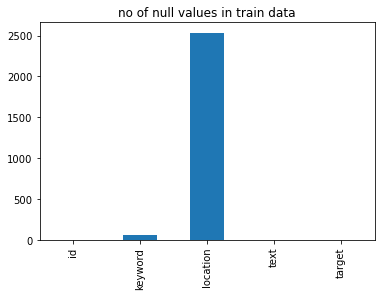

In [13]:
train_df.isna().sum().plot(kind="bar")
plt.title("no of null values in train data")
plt.show()

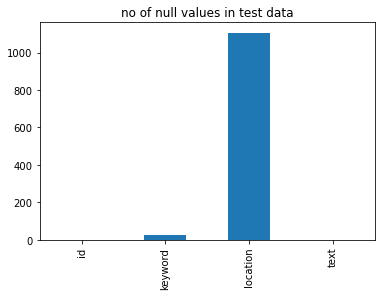

In [14]:
test_df.isna().sum().plot(kind="bar")
plt.title("no of null values in test data")
plt.show()

**We do not need location and keyword columns.So we are going to drop these two columns**

In [15]:
# drop location and keyword column
train_df = train_df.drop(['location','keyword'],axis=1)
test_df = test_df.drop(['location','keyword'],axis=1)

In [16]:
# train dataset after dropping location and keyword columns
train_df.head()

,id,text,target
0,1,Our Deeds are the Reason of this #earthquake M...,1
1,4,Forest fire near La Ronge Sask. Canada,1
2,5,All residents asked to 'shelter in place' are ...,1
3,6,"13,000 people receive #wildfires evacuation or...",1
4,7,Just got sent this photo from Ruby #Alaska as ...,1


In [17]:
# test dataset after dropping location and keyword columns
test_df.head()

,id,text
0,0,Just happened a terrible car crash
1,2,"Heard about #earthquake is different cities, s..."
2,3,"there is a forest fire at spot pond, geese are..."
3,9,Apocalypse lighting. #Spokane #wildfires
4,11,Typhoon Soudelor kills 28 in China and Taiwan


In [18]:
# finding percentage of 0 and 1 target
real_tweets = len(train_df[train_df["target"] == 1])
real_tweets_percentage = real_tweets/train_df.shape[0]*100
fake_tweets_percentage = 100-real_tweets_percentage

#print
print("Real tweets percentage: ",real_tweets_percentage)
print("Fake tweets percentage: ",fake_tweets_percentage)

Real tweets percentage:  42.96597924602653
Fake tweets percentage:  57.03402075397347


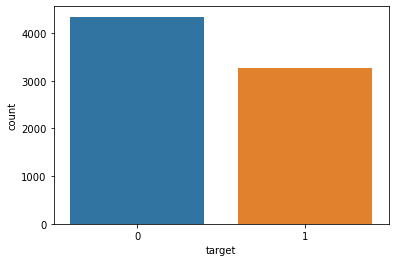

In [19]:
# plot of traget values
sns.countplot(x='target',data=train_df)

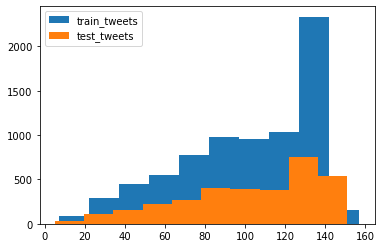

In [20]:
length_train = train_df['text'].str.len() 
length_test = test_df['text'].str.len() 
plt.hist(length_train, label="train_tweets") 
plt.hist(length_test, label="test_tweets") 
plt.legend() 
plt.show()

In [21]:
# disaster tweets
disaster_tweets = train_df[train_df['target'] ==1 ]['text']
for i in range(1,10):
    print(disaster_tweets[i])

Forest fire near La Ronge Sask. Canada
All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
13,000 people receive #wildfires evacuation orders in California 
Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 
#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires
#flood #disaster Heavy rain causes flash flooding of streets in Manitou, Colorado Springs areas
I'm on top of the hill and I can see a fire in the woods...
There's an emergency evacuation happening now in the building across the street
I'm afraid that the tornado is coming to our area...


In [22]:
# non-disaster tweets
non_disaster_tweets = train_df[train_df['target'] !=1 ]['text']

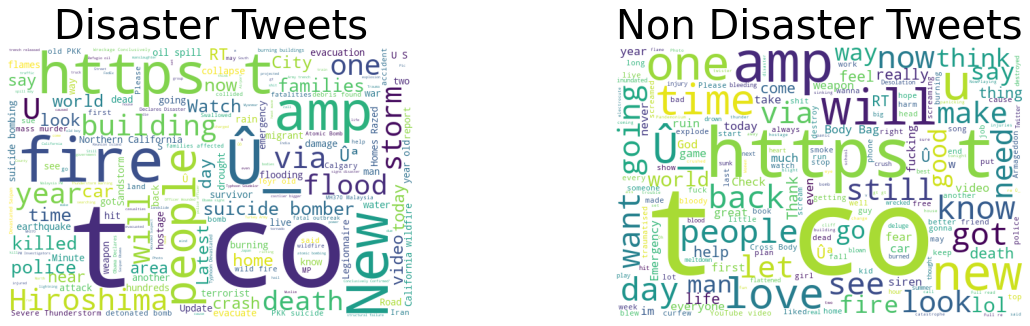

In [23]:
# word cloud of disaster and non-disaster tweets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[20, 5])
wordcloud1 = WordCloud( background_color='white',
                        width=600,
                        height=400).generate(" ".join(disaster_tweets))
ax1.imshow(wordcloud1)
ax1.axis('off')
ax1.set_title('Disaster Tweets',fontsize=40);

wordcloud2 = WordCloud( background_color='white',
                        width=600,
                        height=400).generate(" ".join(non_disaster_tweets))
ax2.imshow(wordcloud2)
ax2.axis('off')
ax2.set_title('Non Disaster Tweets',fontsize=40);

# Data Cleaning

In [24]:
# cleaning the text

def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

# Applying the cleaning function to both test and train datasets
train_df['text'] = train_df['text'].apply(lambda x: clean_text(x))
test_df['text'] = test_df['text'].apply(lambda x: clean_text(x))

# updated text
train_df['text'].head()

0    our deeds are the reason of this earthquake ma...
1                forest fire near la ronge sask canada
2    all residents asked to shelter in place are be...
3     people receive wildfires evacuation orders in...
4    just got sent this photo from ruby alaska as s...
Name: text, dtype: object

In [25]:
tokenizer=nltk.tokenize.RegexpTokenizer(r'\w+')
train_df['text'] = train_df['text'].apply(lambda x:tokenizer.tokenize(x))
test_df['text'] = test_df['text'].apply(lambda x:tokenizer.tokenize(x))
train_df['text'].head()

0    [our, deeds, are, the, reason, of, this, earth...
1        [forest, fire, near, la, ronge, sask, canada]
2    [all, residents, asked, to, shelter, in, place...
3    [people, receive, wildfires, evacuation, order...
4    [just, got, sent, this, photo, from, ruby, ala...
Name: text, dtype: object

# Stopwords

Stopwords are those english words which do not add much meaning to a sentence.They are very commonly used words and we do not required those words.
So we can remove those stopwords

In [26]:
# stopwords
stopwords.words('english')

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [27]:
len(stopwords.words('english'))

179

In [28]:
# removing stopwords
def remove_stopwords(text):
    words = [w for w in text if w not in stopwords.words('english')]
    return words 
train_df['text'] = train_df['text'].apply(lambda x : remove_stopwords(x))
test_df['text'] = test_df['text'].apply(lambda x : remove_stopwords(x))
test_df.head()

,id,text
0,0,"[happened, terrible, car, crash]"
1,2,"[heard, earthquake, different, cities, stay, s..."
2,3,"[forest, fire, spot, pond, geese, fleeing, acr..."
3,9,"[apocalypse, lighting, spokane, wildfires]"
4,11,"[typhoon, soudelor, kills, china, taiwan]"


# Lemmatization 

Lemmatization is the process of grouping  together the different inflected forms of a word so they can be analyzed as a single item. 

Examples of lemmatization:

1.**playing** ,**plays** and **played** all these 3 letters will be converted to **play** after lemmatization

2.**change** , **changing** , **changes** , **changed** and **changer** all these letters will be converted to **change** after lemmatization

In [29]:
# lemmatization
lem = WordNetLemmatizer()
def lem_word(x):
    return [lem.lemmatize(w) for w in x]

In [30]:
train_df['text'] = train_df['text'].apply(lem_word)
test_df['text'] = test_df['text'].apply(lem_word)

In [31]:
train_df['text'][:10]

0    [deed, reason, earthquake, may, allah, forgive...
1        [forest, fire, near, la, ronge, sask, canada]
2    [resident, asked, shelter, place, notified, of...
3    [people, receive, wildfire, evacuation, order,...
4    [got, sent, photo, ruby, alaska, smoke, wildfi...
5    [rockyfire, update, california, hwy, closed, d...
6    [flood, disaster, heavy, rain, cause, flash, f...
7                     [im, top, hill, see, fire, wood]
8    [there, emergency, evacuation, happening, buil...
9                  [im, afraid, tornado, coming, area]
Name: text, dtype: object

In [32]:
def combine_text(list_of_text):
    '''Takes a list of text and combines them into one large chunk of text.'''
    combined_text = ' '.join(list_of_text)
    return combined_text

train_df['text'] = train_df['text'].apply(lambda x : combine_text(x))
test_df['text'] = test_df['text'].apply(lambda x : combine_text(x))
train_df['text']
train_df.head()

,id,text,target
0,1,deed reason earthquake may allah forgive u,1
1,4,forest fire near la ronge sask canada,1
2,5,resident asked shelter place notified officer ...,1
3,6,people receive wildfire evacuation order calif...,1
4,7,got sent photo ruby alaska smoke wildfire pour...,1


# Count-Vector

CountVectorizer is used to transform a given text into a vector on the basis of the frequency(count) of each word that occurs in the entire text.It involves counting the number of occurences each words appears in a document(text) 

In [33]:
count_vectorizer = CountVectorizer()
train_vector = count_vectorizer.fit_transform(train_df['text'])
test_vector = count_vectorizer.transform(test_df['text'])
print(train_vector[0].todense())

[[0 0 0 ... 0 0 0]]


# TF-IDF

It stands for Term Frequency-Inverse document frequency.It is a techinque to quantify a word in documents,we generally compute a weight to each word which signifies the importance of the word which signifies the importance of the word in the document and corpus

In [34]:
tfidf = TfidfVectorizer(min_df = 2,max_df = 0.5,ngram_range = (1,2))
train_tfidf = tfidf.fit_transform(train_df['text'])
test_tfidf = tfidf.transform(test_df['text'])

# XGB Classifier

In [35]:
xgb_param = xgb.XGBClassifier(max_depth=5,n_estimators=500,colsample_bytree=0.8,nthread=10,learning_rate=0.05)

In [36]:
scores_vector = model_selection.cross_val_score(xgb_param,train_vector,train_df['target'],cv=5,scoring='f1')
scores_vector

array([0.49032258, 0.35832522, 0.44927536, 0.37486688, 0.50185874])

In [37]:
scores_tfidf = model_selection.cross_val_score(xgb_param,train_tfidf,train_df['target'],cv=5,scoring='f1')
scores_tfidf

array([0.48131868, 0.3733863 , 0.46690519, 0.36051502, 0.53755656])

In [38]:
xgb_param.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.8,
 'gamma': None,
 'gpu_id': None,
 'importance_type': 'gain',
 'interaction_constraints': None,
 'learning_rate': 0.05,
 'max_delta_step': None,
 'max_depth': 5,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'n_estimators': 500,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None,
 'nthread': 10}

# MultiNomial Naive Bayes

In [39]:
mnb = MultinomialNB(alpha = 2.0)
scores_vector = model_selection.cross_val_score(mnb,train_vector,train_df['target'],cv = 10,scoring = 'f1')
print("score:",scores_vector)
scores_tfidf = model_selection.cross_val_score(mnb,train_tfidf,train_df['target'],cv = 10,scoring = 'f1')
print("score of tfidf:",scores_tfidf)

score: [0.69207317 0.5512605  0.58394161 0.53465347 0.66951567 0.62831858
 0.6735905  0.6029654  0.7107438  0.74614306]
score of tfidf: [0.6221374  0.47157895 0.58844765 0.46616541 0.59507042 0.50929368
 0.59107807 0.51639344 0.71890971 0.75409836]


In [40]:
mnb.get_params()

{'alpha': 2.0, 'class_prior': None, 'fit_prior': True}

# Logistic Regression

In [41]:
lg = LogisticRegression(C = 1.0)
scores_vector = model_selection.cross_val_score(lg, train_vector, train_df["target"], cv = 5, scoring = "f1")
print("score:",scores_vector)
scores_tfidf = model_selection.cross_val_score(lg, train_tfidf, train_df["target"], cv = 5, scoring = "f1")
print("score of tfidf:",scores_tfidf)

score: [0.61904762 0.53401361 0.58340181 0.53521127 0.69756481]
score of tfidf: [0.58502024 0.50644567 0.54725473 0.48190279 0.66840731]


In [42]:
lg.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

# Prediction

In [43]:
mnb.fit(train_tfidf, train_df["target"])
y_pred = mnb.predict(test_tfidf)

In [44]:
y_pred

array([1, 0, 1, ..., 1, 1, 1])

**Now we will prepare submission file**

# Submission

In [45]:
submission_df2 = pd.DataFrame({'Id':test_df['id'],'target':y_pred})

In [46]:
submission_df2.to_csv('submission_df2.csv',index=False)

In [47]:
submission_df2 = pd.read_csv('submission_df2.csv')

In [48]:
submission_df2.head()

,Id,target
0,0,1
1,2,0
2,3,1
3,9,1
4,11,1
